# RRT* Demo: Rewiring for Better Paths

This notebook teaches how RRT* improves on RRT by optimizing tree structure over time.

What you will learn:
- how RRT* chooses a better parent for each new node,
- how local rewiring lowers path cost,
- why RRT* is typically slower but yields better solutions.

Suggested exploration:
- increase `max_iters` and track path cost,
- compare behavior with different `neighbor_radius` values.

In [10]:
%matplotlib inline

from collections import defaultdict
import math
import random

import matplotlib.pyplot as plt
import numpy as np

## 1. Build map and planning query

We use a map with narrow passages so rewiring has visible effects on route quality.

In [11]:
H, W = 60, 60
grid = np.zeros((H, W), dtype=np.uint8)

grid[10:50, 24] = 1
grid[10:50, 36] = 1
grid[30, 24:37] = 1
grid[14, 24] = 0
grid[46, 36] = 0
grid[30, 30] = 0

start = (5.0, 5.0)
goal = (55.0, 55.0)

## 2. Shared geometry and collision checks

These helper functions are the same backbone used by both RRT and RRT*.

In [12]:
def in_bounds(r, c):
    return 0 <= r < H and 0 <= c < W

def free_point(p):
    r, c = int(round(p[0])), int(round(p[1]))
    return in_bounds(r, c) and grid[r, c] == 0

def dist(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def line_free(a, b):
    # Check the cells touched by densely sampled points so edges cannot squeeze through obstacle boundaries.
    n = max(1, int(math.ceil(dist(a, b) * 20)))
    for i in range(n + 1):
        t = i / n
        rr = a[0] + t * (b[0] - a[0])
        cc = a[1] + t * (b[1] - a[1])
        rows = {int(math.floor(rr)), int(math.ceil(rr))}
        cols = {int(math.floor(cc)), int(math.ceil(cc))}
        for r in rows:
            for c in cols:
                if not in_bounds(r, c) or grid[r, c] != 0:
                    return False
    return True

## 3. Run RRT* with parent selection and rewiring

Core improvements over RRT in this cell:
- best-parent selection among nearby nodes,
- rewiring neighbors when a cheaper route is found,
- propagating rewiring cost changes through affected subtrees.

Observation prompt:
- increasing `neighbor_radius` can improve quality but adds computation.

Implementation note: this demo uses a linear nearest-neighbor scan for clarity, so nearest-node lookup is `O(N)` per iteration. Production implementations usually accelerate neighbor queries with spatial data structures such as KD-trees.

Goal-handling note: the demo keeps a single explicit goal node once the tree first reaches the goal region, which is simple for teaching but still more constrained than full production-style goal handling.

In [16]:
rng = random.Random(29)
step_len = 2.0
neighbor_radius = 4.5
goal_radius = 2.5
goal_bias = 0.1
max_iters = 13500

nodes = [start]
parent = {0: None}
children = defaultdict(list)
cost = {0: 0.0}
goal_idx = None

def set_parent(child_idx, new_parent_idx):
    old_parent_idx = parent.get(child_idx)
    if old_parent_idx is not None and child_idx in children[old_parent_idx]:
        children[old_parent_idx].remove(child_idx)
    parent[child_idx] = new_parent_idx
    if new_parent_idx is not None and child_idx not in children[new_parent_idx]:
        children[new_parent_idx].append(child_idx)

def propagate_costs_from(root_idx):
    queue = [root_idx]
    while queue:
        node_idx = queue.pop(0)
        for child_idx in children[node_idx]:
            cost[child_idx] = cost[node_idx] + dist(nodes[node_idx], nodes[child_idx])
            queue.append(child_idx)

for _ in range(max_iters):
    if rng.random() < goal_bias:
        sample = goal
    else:
        sample = (rng.uniform(0, H - 1), rng.uniform(0, W - 1))

    # Linear scan is fine for a small demo; larger systems usually use KD-trees here.
    near_i = min(range(len(nodes)), key=lambda i: dist(nodes[i], sample))
    near = nodes[near_i]
    d = dist(near, sample)
    if d < 1e-9:
        continue

    t = min(step_len / d, 1.0)
    new = (near[0] + t * (sample[0] - near[0]), near[1] + t * (sample[1] - near[1]))
    if not free_point(new):
        continue
    if not line_free(near, new):
        continue

    nearby = [i for i, p in enumerate(nodes) if dist(p, new) <= neighbor_radius and line_free(p, new)]
    if near_i not in nearby:
        nearby.append(near_i)

    best_parent = min(nearby, key=lambda i: cost[i] + dist(nodes[i], new))
    best_cost = cost[best_parent] + dist(nodes[best_parent], new)

    nodes.append(new)
    ni = len(nodes) - 1
    cost[ni] = best_cost
    set_parent(ni, best_parent)

    for i in nearby:
        cand = cost[ni] + dist(nodes[ni], nodes[i])
        if cand + 1e-9 < cost[i] and line_free(nodes[ni], nodes[i]):
            set_parent(i, ni)
            cost[i] = cand
            propagate_costs_from(i)

    # This demo keeps a single explicit goal node after the first goal connection.
    if dist(new, goal) <= goal_radius and line_free(new, goal):
        new_goal_cost = cost[ni] + dist(new, goal)
        if goal_idx is None:
            nodes.append(goal)
            goal_idx = len(nodes) - 1
            cost[goal_idx] = new_goal_cost
            set_parent(goal_idx, ni)
        elif new_goal_cost + 1e-9 < cost[goal_idx]:
            cost[goal_idx] = new_goal_cost
            set_parent(goal_idx, ni)

print('Nodes:', len(nodes), 'Goal connected:', goal_idx is not None)

Nodes: 11387 Goal connected: True


## 4. Recover final route and compute path cost

Backtracking through `parent` gives the final route. Cost reflects how well rewiring improved connectivity.

In [17]:
path = []
if goal_idx is not None:
    cur = goal_idx
    while cur is not None:
        path.append(nodes[cur])
        cur = parent[cur]
    path.reverse()

path_cost = 0.0
for i in range(len(path) - 1):
    path_cost += dist(path[i], path[i + 1])

print('Path points:', len(path), 'Path cost:', round(path_cost, 2))

Path points: 26 Path cost: 81.0


## 5. Visual analysis and comparison exercise

Try this quick comparison exercise:
1. Run with `max_iters = 800` and note path cost.
2. Run with `max_iters = 3500` and compare.
3. Contrast the result with plain RRT on the same map.

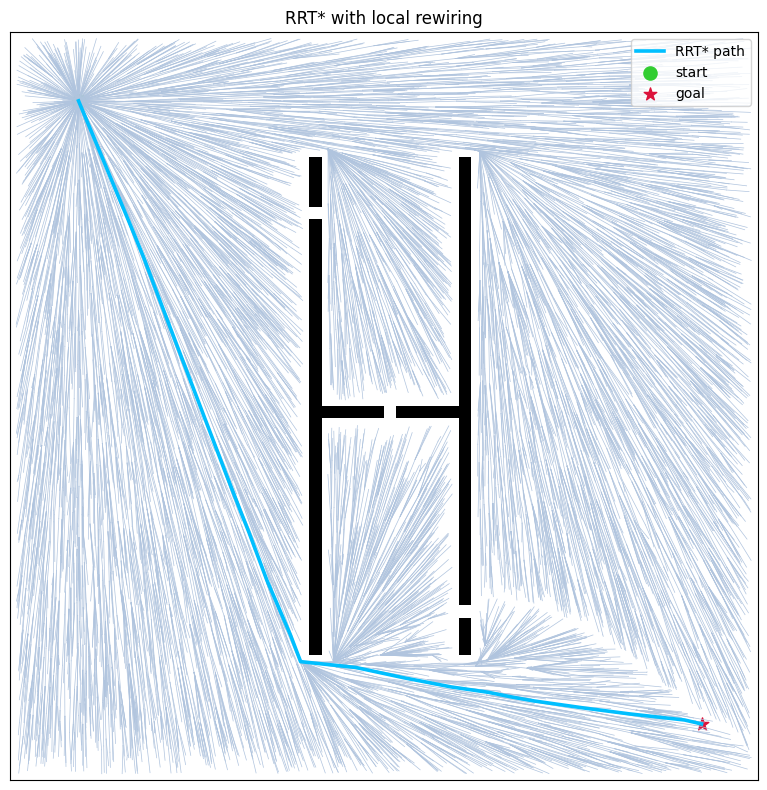

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(grid, cmap='Greys', origin='upper')

for i in range(1, len(nodes)):
    pi = parent.get(i)
    if pi is None:
        continue
    a, b = nodes[pi], nodes[i]
    ax.plot([a[1], b[1]], [a[0], b[0]], color='lightsteelblue', linewidth=0.5)

if path:
    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    ax.plot(xs, ys, color='deepskyblue', linewidth=2.6, label='RRT* path')

ax.scatter(start[1], start[0], c='limegreen', s=90, marker='o', label='start')
ax.scatter(goal[1], goal[0], c='crimson', s=90, marker='*', label='goal')
ax.set_title('RRT* with local rewiring')
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()